In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd ..

/Users/leonmac/Codes/BO-Set


# Synthetic Experiments
- BA graph ws grid: 100 nodes
- all the kernels
- Plot r-1
- Plot validation error plot

In [3]:
import numpy as np
import torch
import random
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
import itertools
import multiprocessing
import yaml
import time
import os
from math import comb
from functools import partial
from scipy.stats import spearmanr
from tqdm.std import tqdm

import utils.config_utils as config_utils
from problems.underlying_problem import get_synthetic_problem
from search.trust_region import restart
from search.utils import eigendecompose_laplacian
from search.models import initialize_model
from search.self_combograph import ComboSubgraph_Constructor
from botorch.utils.transforms import standardize

seed=0
np.random.seed(seed)
random.seed(seed)

In [4]:
### Define graph
def underlying_graph(config):
    # graph_type = grid, ba, ws
    base_problem = get_synthetic_problem(
        label=config["problem_name"], 
        seed=0,
        problem_kwargs=config["problem_settings"])
    return base_problem

def initialize(Graph):
    X_train = torch.empty(0,1)
    Y_train = torch.empty(0,1)
    base_model, base_mll, based_cached_eigenbasis = initialize_model(
                    train_X=X_train,
                    train_Y=Y_train,
                    context_graph=Graph,
                    covar_type="diffusion",
                    covar_kwargs = {"order": 1},
                    fit_model=False,
                    ard=True,
                    use_fixed_noise=False,
                    use_saas_map=False)
    pos = nx.kamada_kawai_layout(Graph)
    return base_model, pos # base_mll, based_cached_eigenbasis

def output_model(covar_type, X_train, Y_train, Graph, Q):
    if covar_type in ["polynomial", "polynomial_suminverse"]:
        model, mll, cached_eigenbasis = initialize_model(
                    train_X=X_train,
                    train_Y=Y_train,
                    context_graph=Graph,
                    covar_type=covar_type,
                    covar_kwargs = {"order": None},
                    fit_model=True,
                    ard=True,)
    elif covar_type == "diffusion":
        model, mll, cached_eigenbasis = initialize_model(
                    train_X=X_train,
                    train_Y=Y_train,
                    context_graph=Graph,
                    covar_type=covar_type,
                    covar_kwargs = {"order": None},
                    fit_model=True,
                    ard=False,)
    elif covar_type == "diffusion_ard":
        model, mll, cached_eigenbasis = initialize_model(
                    train_X=X_train,
                    train_Y=Y_train,
                    context_graph=Graph,
                    covar_type="diffusion",
                    covar_kwargs = {"order": None},
                    fit_model=True,
                    ard=True,)
    return model, mll, cached_eigenbasis

In [5]:
# Map the indices of nodes on combinatorial graph to numerical indices
def Index_Mapper(Graph):  # e.g. (2,8,13)-> 3, we need numerical indices for kernel computation
    node_list = [i for i in Graph.nodes()]
    mapping = {old_node: new_idx for new_idx, old_node in enumerate(node_list, start=0)}
    return nx.relabel_nodes(Graph, mapping)

# Define signal
def underlying_signal(base_model, j=2):
    all_X = torch.arange(len(problem.underlying_graph)).to(torch.float)
    all_Y = base_model.covar_module.base_kernel.eigenbasis[:,j].detach().clone()
    return all_X, all_Y

def get_signal(problem, ComboSubgraph, prop_data = 0.25):
    all_Y = problem.evaluate_true(torch.tensor(list(ComboSubgraph.nodes))).squeeze()
    ComboSubGraph_mapped = Index_Mapper(ComboSubgraph)
    all_X = torch.arange(len(ComboSubGraph_mapped)).to(torch.float)
    
    from botorch.utils.transforms import standardize
    n_init = len(all_X)
    X = all_X.reshape(-1, 1).detach().clone()

    # Y = base_problem(X.reshape(-1, 1))
    Y = all_Y.reshape(-1, 1).to(dtype=torch.float).detach().clone()
    Y = standardize(Y)

    best_loc = Y.argmax().item()
    X_best = X[best_loc]

    n_train = int(n_init * prop_data)
    ntrain_indices = np.random.choice(n_init, n_train, replace=False)
    ntest_indices = np.array([i for i in range(n_init) if i not in ntrain_indices])
    X_train, Y_train = X[ntrain_indices, ...], Y[ntrain_indices]
    X_test, Y_test = X[ntest_indices, ...], Y[ntest_indices, ...]
    return all_X, Y.squeeze(), X_train, Y_train, X_test, Y_test, X_best

def get_signal_noise(problem, ComboSubgraph, prop_data = 0.25, sigma = 0.1):
    all_Y = problem.evaluate_true(torch.tensor(list(ComboSubgraph.nodes))).squeeze()
    ComboSubGraph_mapped = Index_Mapper(ComboSubgraph)
    all_X = torch.arange(len(ComboSubGraph_mapped)).to(torch.float)

    n_init = len(all_X)
    X = all_X.reshape(-1, 1).detach().clone()

    # Y = base_problem(X.reshape(-1, 1))
    Y = all_Y.reshape(-1, 1).to(dtype=torch.float).detach().clone()
    Y = standardize(Y)
    Y += torch.tensor(np.random.normal(scale=sigma, size = Y.shape))

    best_loc = Y.argmax().item()
    X_best = X[best_loc]

    n_train = int(n_init * prop_data)
    ntrain_indices = np.random.choice(n_init, n_train, replace=False)
    ntest_indices = np.array([i for i in range(n_init) if i not in ntrain_indices])
    X_train, Y_train = X[ntrain_indices, ...], Y[ntrain_indices]
    X_test, Y_test = X[ntest_indices, ...], Y[ntest_indices, ...]
    return all_X, Y.squeeze(), X_train, Y_train, X_test, Y_test, X_best

In [6]:
def plot_signal(ax_signal, Graph, signal, pos, y_label="(a)"):
    nodes = Graph.nodes()
    node_size=50
    nx.draw_networkx(Graph, pos, with_labels=False, ax = ax_signal, node_size=node_size)
    nc = nx.draw_networkx_nodes(Graph, pos, nodelist=nodes, node_color=signal, node_size=node_size, cmap=mpl.colormaps['Blues'], ax = ax_signal)
    #plt.colorbar(nc, ax=ax_signal, boundaries=np.linspace(-0.25,0.25,11))
    plt.colorbar(nc, ax=ax_signal)
    ax_signal.set_axis_off()
    ax_signal.text(-0.9, 0.8, y_label, fontsize=20.)

def plot_validation(ax_kernel, model, X_test, Y_test, title = None):
    model.eval()
    with torch.no_grad():
        # predict on train input
        Y_test_pred = model.posterior(X_test)
        Y_test_pred_mean, Y_test_pred_std = Y_test_pred.mean.flatten(), torch.sqrt(Y_test_pred.variance).flatten()
        ax_kernel.plot(Y_test, Y_test_pred_mean, ".")
        ax_kernel.errorbar(Y_test, Y_test_pred_mean, yerr=Y_test_pred_std, linestyle="None", color="C0", alpha=0.3)
        ax_kernel.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], color="gray", linestyle='--')
        ax_kernel.text(-2, 2, r'$\rho$' + f" : {round(spearmanr(Y_test_pred_mean, Y_test)[0], 2)}")
        ax_kernel.set_xlabel("Validation ground truth")
        if title is not None:
            ax_kernel.set_title(title)

def plot_rinverse(ax_kernel, model):
    ax_kernel.plot(model.covar_module.base_kernel.eigenvalues.detach(), torch.diag(model.covar_module.base_kernel.get_dist()).detach())
    ax_kernel.ticklabel_format(style='sci', scilimits=(-1,1))

In [7]:
# Get the underlying function f: the Eigenvector that correspondes to the j-th Eigenvalue
yaml_path = 'configurations/kernel_validation.yaml'
config = config_utils.setup(yaml_path)
pb_kwargs = config["problem_settings"]

j=2
k, Q = config["problem_settings"]["k"], config["bo_settings"]["Q"]
problem = underlying_graph(config)
base_model, pos = initialize(problem.underlying_graph)
#original_X, original_Y = underlying_signal(base_model, j=j)

Using BA network (n=1000 m=3) with eigenvector_centrality
feature_computation...........


/Users/leonmac/anaconda3/lib/python3.11/site-packages/botorch/models/gp_regression.py:161: UserWarning: The model inputs are of type torch.float32. It is strongly recommended to use double precision in BoTorch, as this improves both precision and stability and can help avoid numerical errors. See https://github.com/pytorch/botorch/discussions/1444
  self._validate_tensor_args(X=transformed_X, Y=train_Y, Yvar=train_Yvar)


In [8]:
# Get the synthetic problem: the mean of f across sets of k-node combinations on a random ComboSubgraph of size Q
ComboNode = random.sample(list(problem.underlying_graph.nodes), k) # Sample a random ComboNode as ComboSubgraph centre
ComboNode.sort() # Very important to sort the ComboNode!
ComboNode = tuple(ComboNode)
print(f"Number of all possible ComboNodes: {comb(problem.underlying_graph.number_of_nodes(), k):.2E}")
print("ComboNode for the ComboSubgraph Centre:", ComboNode)
ComboSubgraph = ComboSubgraph_Constructor(problem.underlying_graph, np.array(ComboNode).reshape(1,-1), nx.Graph(), Q=Q)
_, pos_ = initialize(ComboSubgraph)

all_X, all_Y, X_train, Y_train, X_test, Y_test, X_best = get_signal(problem, ComboSubgraph, prop_data = 0.5)

Number of all possible ComboNodes: 4.14E+10
ComboNode for the ComboSubgraph Centre: (137, 582, 821, 867)
number of new neighbors at hop 1: 16
number of new neighbors at hop 2: 394
number of new neighbors at hop 3: 5266


In [9]:
if Q <= 100:
    fig, ax = plt.subplots(1,2, figsize=(18, 5), gridspec_kw={'width_ratios': [1,1]})

    # -------------- Plot the Original Graph ----------------
    g = base_problem.underlying_graph
    nodes = g.nodes()
    colors = original_Y
    node_size = 150

    nx.draw_networkx(g, pos, with_labels=True, node_size=node_size, ax=ax[0])
    ec = nx.draw_networkx_edges(g, pos, alpha=0.2, ax=ax[0])
    nc = nx.draw_networkx_nodes(g, pos, nodelist=nodes, node_color=colors, ax=ax[0],
                                node_size=node_size*0.8, cmap=mpl.colormaps['Blues'])
    plt.colorbar(nc)
    ax[0].set_axis_off()

    # -------------- Plot a Random ComboSubgraph ----------------
    nodes = ComboSubgraph.nodes()
    colors = all_Y

    nx.draw_networkx(ComboSubgraph, pos_, with_labels=True, node_size=node_size, ax=ax[1])
    ec = nx.draw_networkx_edges(ComboSubgraph, pos_, alpha=0.2, ax=ax[1])
    nc = nx.draw_networkx_nodes(ComboSubgraph, pos_, nodelist=nodes, node_color=colors, ax=ax[1],
                                node_size=node_size*0.8, cmap=mpl.colormaps['Blues'])
    plt.colorbar(nc)

    ax[1].set_axis_off()

    plt.show()

In [10]:
all_Y.max()

tensor(6.5206)

### Compute results for all models

In [11]:
kernels = ["polynomial","polynomial_suminverse","diffusion","diffusion_ard"]
models = []
models_r = []
sigma = 0.1
prop_train = 0.05

## Smooth signal
all_X, all_Y, X_train, Y_train, X_test, Y_test, X_best = get_signal(problem,
                                                                    ComboSubgraph, 
                                                                    prop_data = prop_train)
for kernel in kernels:
    start_time = time.time()
    models.append(output_model(kernel, X_train, Y_train, ComboSubgraph, Q)[0])
    end_time = time.time()
    print(f"{kernel} kernel finished in {round(end_time - start_time,1)}s")

## Rough signal
all_X_r, all_Y_r, X_train_r, Y_train_r, X_test_r, Y_test_r, X_best_r = get_signal_noise(problem,
                                                                                        ComboSubgraph,
                                                                                        prop_data = prop_train, 
                                                                                        sigma = sigma)
for kernel in kernels:
    start_time = time.time()
    models_r.append(output_model(kernel, X_train_r, Y_train_r, ComboSubgraph, Q)[0])
    end_time = time.time()
    print(f"{kernel} kernel finished in {round(end_time - start_time,1)}s")

/Users/leonmac/anaconda3/lib/python3.11/site-packages/botorch/models/utils/assorted.py:173: InputDataWarning: Input data is not contained to the unit cube. Please consider min-max scaling the input data.
  warnings.warn(msg, InputDataWarning)


polynomial kernel finished in 5.8s


/Users/leonmac/anaconda3/lib/python3.11/site-packages/botorch/models/gp_regression.py:161: UserWarning: The model inputs are of type torch.float32. It is strongly recommended to use double precision in BoTorch, as this improves both precision and stability and can help avoid numerical errors. See https://github.com/pytorch/botorch/discussions/1444
  self._validate_tensor_args(X=transformed_X, Y=train_Y, Yvar=train_Yvar)
/Users/leonmac/anaconda3/lib/python3.11/site-packages/botorch/models/utils/assorted.py:173: InputDataWarning: Input data is not contained to the unit cube. Please consider min-max scaling the input data.
  warnings.warn(msg, InputDataWarning)


polynomial_suminverse kernel finished in 6.0s
diffusion kernel finished in 2.5s
diffusion_ard kernel finished in 2.3s
polynomial kernel finished in 5.2s
polynomial_suminverse kernel finished in 5.9s
diffusion kernel finished in 2.2s
diffusion_ard kernel finished in 2.2s


/var/folders/0p/p2rtjxnd3hgc3cf2jvwg_1fm0000gn/T/ipykernel_45599/1516882739.py:107: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig(f"{save_dir}/KernelValidation-{config['problem_settings']['graph_type']}"
/var/folders/0p/p2rtjxnd3hgc3cf2jvwg_1fm0000gn/T/ipykernel_45599/1516882739.py:107: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig(f"{save_dir}/KernelValidation-{config['problem_settings']['graph_type']}"
/Users/leonmac/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


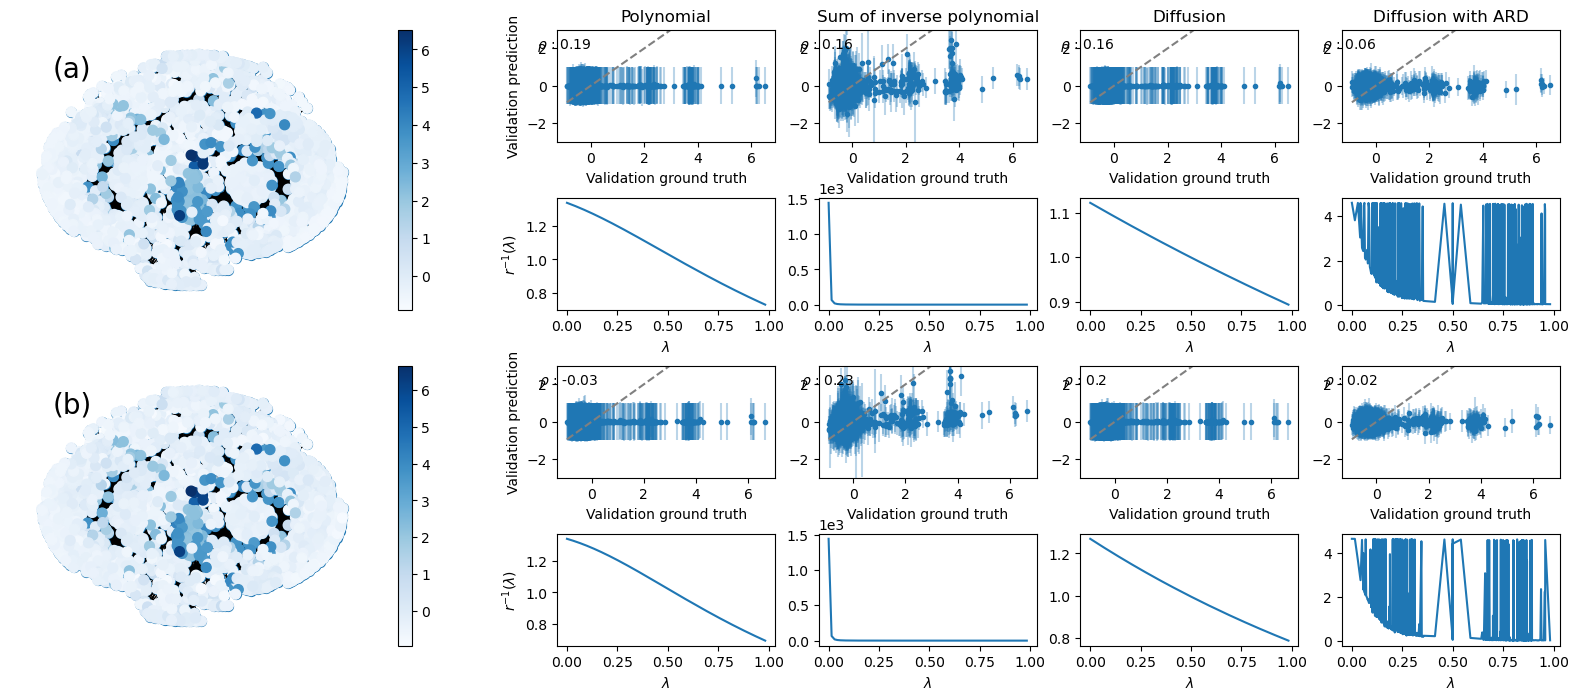

In [12]:
fig = plt.figure(figsize=(20, 8), layout='constrained')
grid = plt.GridSpec(2, 3, hspace=0., wspace=0.2)

signal_ax = fig.add_subplot(grid[:, 0])
signal_ax.set_axis_off()
kernel_subplot = fig.add_subplot(grid[:, 1:])
kernel_subplot.set_axis_off()

inner_signal = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=signal_ax, wspace=0., hspace=0.2)
inner_kernel = gridspec.GridSpecFromSubplotSpec(4, 4, subplot_spec=kernel_subplot, wspace=0.2, hspace=0.5)

signal1_ax = plt.Subplot(fig, inner_signal[0])
signal2_ax = plt.Subplot(fig, inner_signal[1])

kernel11v_ax = plt.Subplot(fig, inner_kernel[0, 0])
kernel11v_ax.set_ylim(-3, 3)
kernel12v_ax = plt.Subplot(fig, inner_kernel[0, 1])
kernel12v_ax.set_ylim(-3, 3)
kernel13v_ax = plt.Subplot(fig, inner_kernel[0, 2])
kernel13v_ax.set_ylim(-3, 3)
kernel14v_ax = plt.Subplot(fig, inner_kernel[0, 3])
kernel14v_ax.set_ylim(-3, 3)

kernel11r_ax = plt.Subplot(fig, inner_kernel[1, 0])
kernel12r_ax = plt.Subplot(fig, inner_kernel[1, 1])
kernel13r_ax = plt.Subplot(fig, inner_kernel[1, 2])
kernel14r_ax = plt.Subplot(fig, inner_kernel[1, 3])

kernel21v_ax = plt.Subplot(fig, inner_kernel[2, 0])
kernel21v_ax.set_ylim(-3, 3)
kernel22v_ax = plt.Subplot(fig, inner_kernel[2, 1])
kernel22v_ax.set_ylim(-3, 3)
kernel23v_ax = plt.Subplot(fig, inner_kernel[2, 2])
kernel23v_ax.set_ylim(-3, 3)
kernel24v_ax = plt.Subplot(fig, inner_kernel[2, 3])
kernel24v_ax.set_ylim(-3, 3)

kernel21r_ax = plt.Subplot(fig, inner_kernel[3, 0])
kernel22r_ax = plt.Subplot(fig, inner_kernel[3, 1])
kernel23r_ax = plt.Subplot(fig, inner_kernel[3, 2])
kernel24r_ax = plt.Subplot(fig, inner_kernel[3, 3])


# Smooth Signal
plot_signal(signal1_ax, ComboSubgraph, all_Y, pos_, y_label="(a)")

plot_validation(kernel11v_ax, models[0], X_test, Y_test, title="Polynomial")
kernel11v_ax.set_ylabel("Validation prediction")
plot_rinverse(kernel11r_ax, models[0])
kernel11r_ax.set_ylabel(r'$r^{-1}(\lambda)$')
kernel11r_ax.set_xlabel(r'$\lambda$')
plot_validation(kernel12v_ax, models[1], X_test, Y_test, title="Sum of inverse polynomial")
plot_rinverse(kernel12r_ax, models[1])
kernel12r_ax.set_xlabel(r'$\lambda$')
plot_validation(kernel13v_ax, models[2], X_test, Y_test, title="Diffusion")
plot_rinverse(kernel13r_ax, models[2])
kernel13r_ax.set_xlabel(r'$\lambda$')
plot_validation(kernel14v_ax, models[3], X_test, Y_test, title="Diffusion with ARD")
plot_rinverse(kernel14r_ax, models[3])
kernel14r_ax.set_xlabel(r'$\lambda$')


## Rough Signal
plot_signal(signal2_ax, ComboSubgraph, all_Y_r, pos_, y_label="(b)")

plot_validation(kernel21v_ax, models_r[0], X_test_r, Y_test_r)
kernel21v_ax.set_ylabel("Validation prediction")
plot_rinverse(kernel21r_ax, models_r[0])
kernel21r_ax.set_ylabel(r'$r^{-1}(\lambda)$')
kernel21r_ax.set_xlabel(r'$\lambda$')
plot_validation(kernel22v_ax, models_r[1], X_test_r, Y_test_r)
plot_rinverse(kernel22r_ax, models_r[1])
kernel22r_ax.set_xlabel(r'$\lambda$')
plot_validation(kernel23v_ax, models_r[2], X_test_r, Y_test_r)
plot_rinverse(kernel23r_ax, models_r[2])
kernel23r_ax.set_xlabel(r'$\lambda$')
plot_validation(kernel24v_ax, models_r[3], X_test_r, Y_test_r)
plot_rinverse(kernel24r_ax, models_r[3])
kernel24r_ax.set_xlabel(r'$\lambda$')

fig.add_subplot(signal1_ax)
fig.add_subplot(signal2_ax)

fig.add_subplot(kernel11v_ax)
fig.add_subplot(kernel12v_ax)
fig.add_subplot(kernel13v_ax)
fig.add_subplot(kernel14v_ax)
fig.add_subplot(kernel11r_ax)
fig.add_subplot(kernel12r_ax)
fig.add_subplot(kernel13r_ax)
fig.add_subplot(kernel14r_ax)


fig.add_subplot(kernel21v_ax)
fig.add_subplot(kernel22v_ax)
fig.add_subplot(kernel23v_ax)
fig.add_subplot(kernel24v_ax)
fig.add_subplot(kernel21r_ax)
fig.add_subplot(kernel22r_ax)
fig.add_subplot(kernel23r_ax)
fig.add_subplot(kernel24r_ax)

save_dir = './experiment_figs/KernelValidation/useless'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

plt.savefig(f"{save_dir}/KernelValidation-{config['problem_settings']['graph_type']}"
            f"-n{config['problem_settings']['n']}-k{k}-Q{Q}-j{j}-sigma{sigma}-prop{prop_train}.pdf", bbox_inches='tight')
plt.show()